# Non i.i.d data (Indeendent and Identically Distributed Data)

- it is quite common to assume that the data are i.i.d, meaning that the generative process does not have any memory of past samples to generate new samples.
- This assumption is usually violated when dealing with time series. A sample depends on past information.


In [2]:
import pandas as pd

symbols = {
    "TOT": "Total",
    "XOM": "Exxon",
    "CVX": "Chevron",
    "COP": "ConocoPhillips",
    "VLO": "Valero Energy",
}
template_name = "data/financial-data/{}.csv"

quotes = {}
for symbol in symbols:
    data = pd.read_csv(
        template_name.format(symbol), index_col=0, parse_dates=True
    )
    quotes[symbols[symbol]] = data["open"]
quotes = pd.DataFrame(quotes)

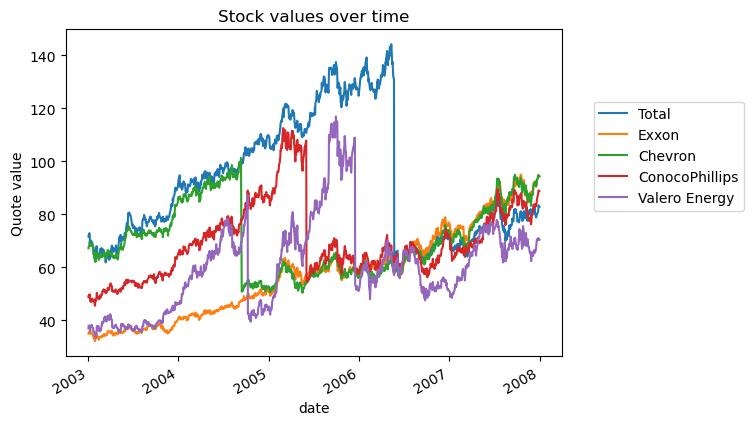

In [3]:
import matplotlib.pyplot as plt

quotes.plot()
plt.ylabel("Quote value")
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = plt.title("Stock values over time")

- we want to predict the quotation of Chevron using all other energy companies' quotes

In [4]:
from sklearn.model_selection import train_test_split

data, target = quotes.drop(columns=["Chevron"]), quotes["Chevron"]
data_train, data_test, target_train, target_test = train_test_split(
    data, target, shuffle=True, random_state=0
)

In [5]:
from sklearn.tree import DecisionTreeRegressor

regressor = DecisionTreeRegressor()

In [6]:
from sklearn.model_selection import ShuffleSplit

cv = ShuffleSplit(random_state=0)

In [7]:
from sklearn.model_selection import cross_val_score

test_score = cross_val_score(
    regressor, data_train, target_train, cv=cv, n_jobs=2
)
print(f"The mean R2 is: {test_score.mean():.2f} ± {test_score.std():.2f}")

The mean R2 is: 0.95 ± 0.07


In [8]:
regressor.fit(data_train, target_train)
target_predicted = regressor.predict(data_test)
# Affect the index of `target_predicted` to ease the plotting
target_predicted = pd.Series(target_predicted, index=target_test.index)

In [9]:
from sklearn.metrics import r2_score

test_score = r2_score(target_test, target_predicted)
print(f"The R2 on this single split is: {test_score:.2f}")

The R2 on this single split is: 0.83


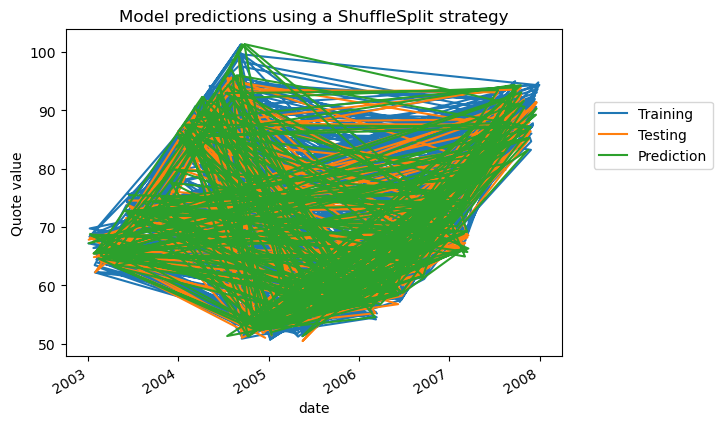

In [10]:
target_train.plot(label="Training")
target_test.plot(label="Testing")
target_predicted.plot(label="Prediction")

plt.ylabel("Quote value")
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = plt.title("Model predictions using a ShuffleSplit strategy")

- a model can output of its training set at the time t for a testing sample at the time t+1. This prediction would be close to the true value even if our model did not learn anything, but just memorized the training dataset.

In [11]:
data_train, data_test, target_train, target_test = train_test_split(
    data,
    target,
    shuffle=False,
    random_state=0,
)
regressor.fit(data_train, target_train)
target_predicted = regressor.predict(data_test)
target_predicted = pd.Series(target_predicted, index=target_test.index)

In [12]:
test_score = r2_score(target_test, target_predicted)
print(f"The R2 on this single split is: {test_score:.2f}")

The R2 on this single split is: -2.22


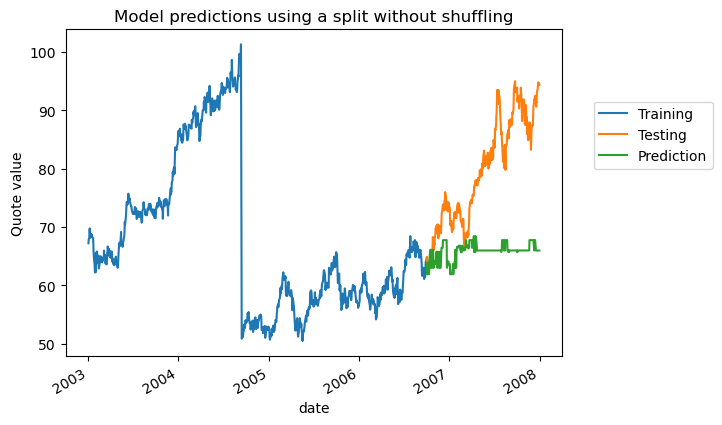

In [13]:
target_train.plot(label="Training")
target_test.plot(label="Testing")
target_predicted.plot(label="Prediction")

plt.ylabel("Quote value")
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = plt.title("Model predictions using a split without shuffling")

- group the samples into time blocks, e.g. by quarter, and predict each group's information by using information from the other groups. We can use the LeaveOneGroupOut cross-validation for this purpose.

In [14]:
from sklearn.model_selection import LeaveOneGroupOut

groups = quotes.index.to_period("Q")
cv = LeaveOneGroupOut()
test_score = cross_val_score(
    regressor, data, target, cv=cv, groups=groups, n_jobs=2
)
print(f"The mean R2 is: {test_score.mean():.2f} ± {test_score.std():.2f}")

The mean R2 is: -0.75 ± 1.60


- our model is aimed at forecasting (i.e., predicting future data from past data), we should not use training data that are ulterior to the testing data. In this case, we can use the TimeSeriesSplit cross-validation to enforce this behaviour.

In [15]:
from sklearn.model_selection import TimeSeriesSplit

cv = TimeSeriesSplit(n_splits=groups.nunique())
test_score = cross_val_score(
    regressor, data, target, cv=cv, groups=groups, n_jobs=2
)
print(f"The mean R2 is: {test_score.mean():.2f} ± {test_score.std():.2f}")

The mean R2 is: -1.62 ± 2.27


C:\Users\KIIT0001\miniconda3\Lib\site-packages\sklearn\model_selection\_split.py:1213: UserWarning: The groups parameter is ignored by TimeSeriesSplit
  warnings.warn(


- In conclusion, it is really important to not use an out of the shelves
cross-validation strategy which do not respect some assumptions such as having
i.i.d data. It might lead to absurd results which could make think that a
predictive model might work.